In [1]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


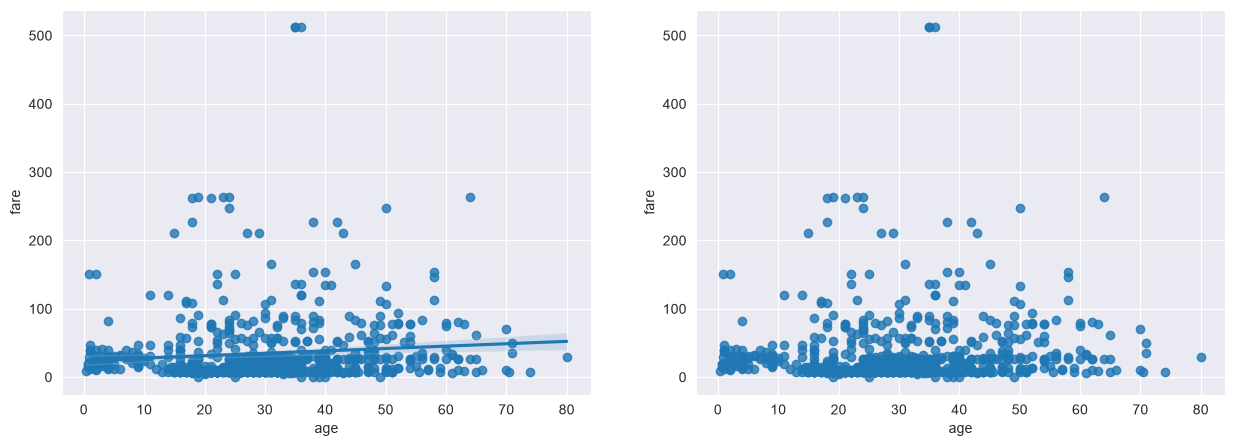

In [2]:
# 회귀선이 있는 산점도

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize = (15,5))

sns.regplot(x='age',       
            y='fare',    
            data=titanic, 
            ax=axes[0])    

sns.regplot(x='age',       
            y='fare',    
            data=titanic, 
            ax=axes[1],   
            fit_reg=False) 

plt.show()

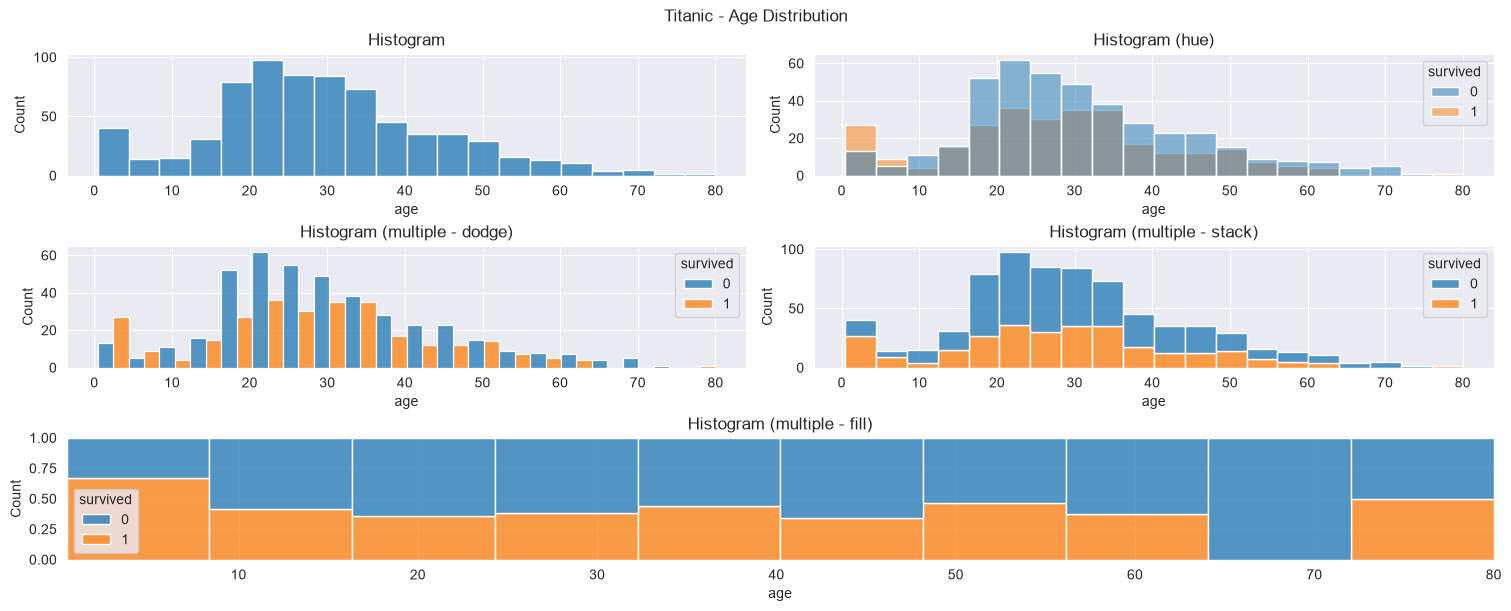

In [3]:
# 히스토그램/커널밀도함수
fig, axes = plt.subplot_mosaic([['top_left', 'top_right'],
                                ['middle_left', 'middle_right'],
                                ['bottom', 'bottom']],
                                figsize=(15, 6),
                                constrained_layout=True)

sns.histplot(x='age', data=titanic,  ax=axes['top_left'])      

sns.histplot(x='age', hue='survived', data=titanic,  ax=axes['top_right'])  

sns.histplot(x='age', hue='survived', multiple='dodge', data=titanic,  ax=axes['middle_left'])  

sns.histplot(x='age', hue='survived', multiple='stack', data=titanic,  ax=axes['middle_right']) 

sns.histplot(x='age', hue='survived', multiple='fill', bins=10, data=titanic,  ax=axes['bottom']) 

fig.suptitle('Titanic - Age Distribution')

axes['top_left'].set_title('Histogram')
axes['top_right'].set_title('Histogram (hue)')
axes['middle_left'].set_title('Histogram (multiple - dodge)')
axes['middle_right'].set_title('Histogram (multiple - stack)')
axes['bottom'].set_title('Histogram (multiple - fill)')

plt.show()

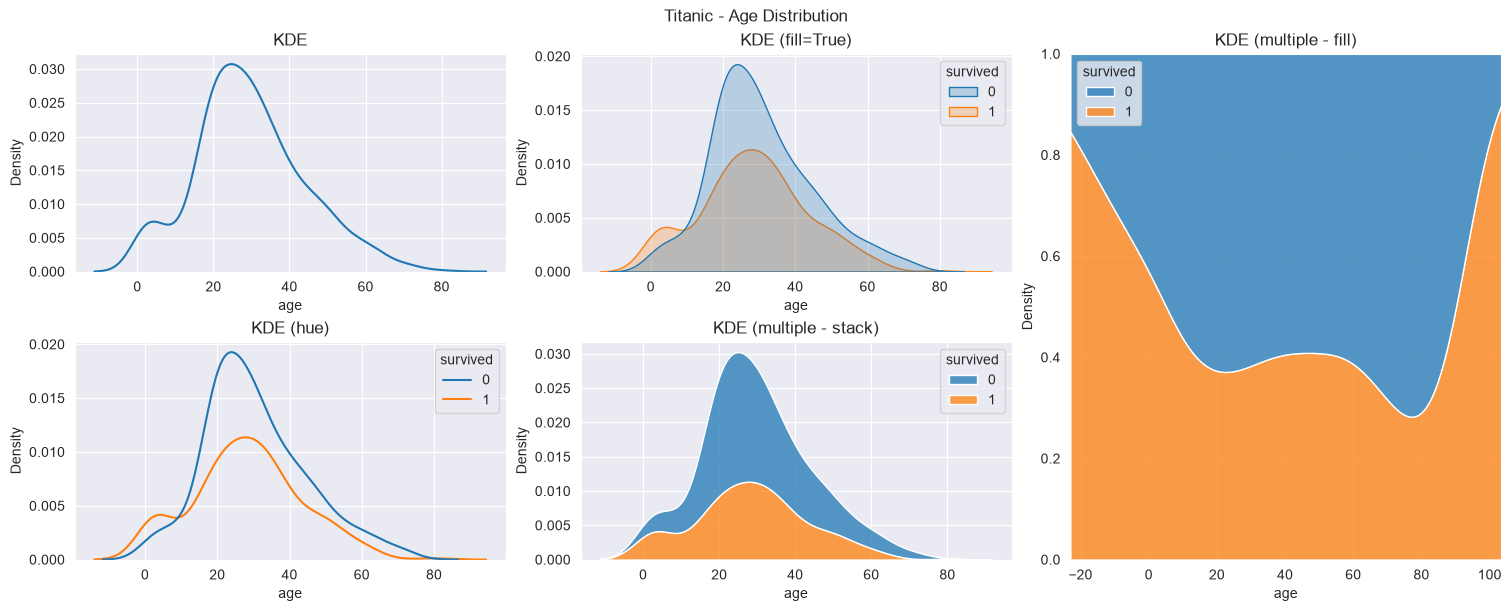

In [4]:
fig, axes = plt.subplot_mosaic([['top_left', 'top_center', 'right'],
                                ['bottom_left', 'bottom_center', 'right']],
                                figsize=(15, 6),
                                constrained_layout=True)

sns.kdeplot(x='age', data=titanic,  ax=axes['top_left'])      

sns.kdeplot(x='age', hue='survived', data=titanic,  ax=axes['bottom_left'])  

sns.kdeplot(x='age', hue='survived', fill=True, data=titanic,  ax=axes['top_center'])  

sns.kdeplot(x='age', hue='survived', multiple='stack', data=titanic,  ax=axes['bottom_center']) 

sns.kdeplot(x='age', hue='survived', multiple='fill', bw_adjust=2.0, data=titanic,  ax=axes['right']) 

fig.suptitle('Titanic - Age Distribution')

axes['top_left'].set_title('KDE')
axes['bottom_left'].set_title('KDE (hue)')
axes['top_center'].set_title('KDE (fill=True)')
axes['bottom_center'].set_title('KDE (multiple - stack)')
axes['right'].set_title('KDE (multiple - fill)')

plt.show()

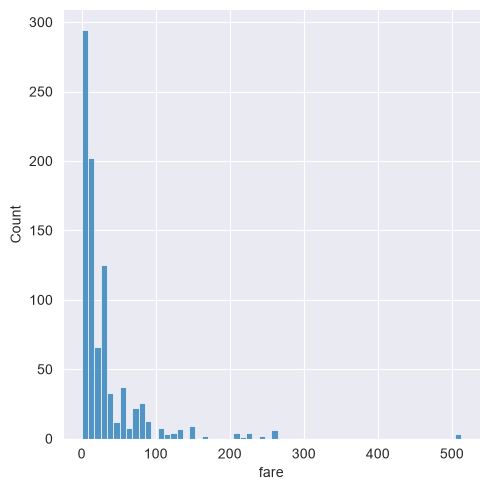

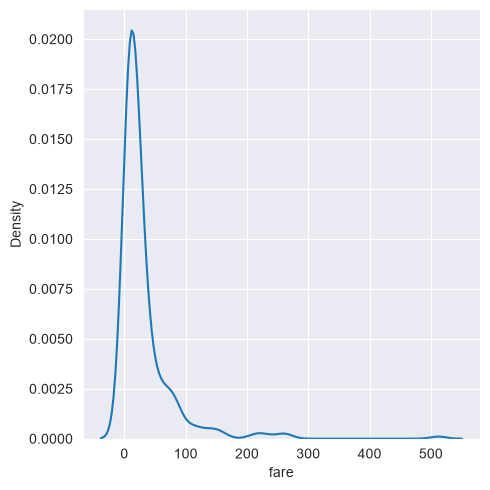

In [5]:
sns.displot(
    titanic["fare"], kind="hist"
)

plt.show()

sns.displot(titanic["fare"], kind="kde")
plt.show()

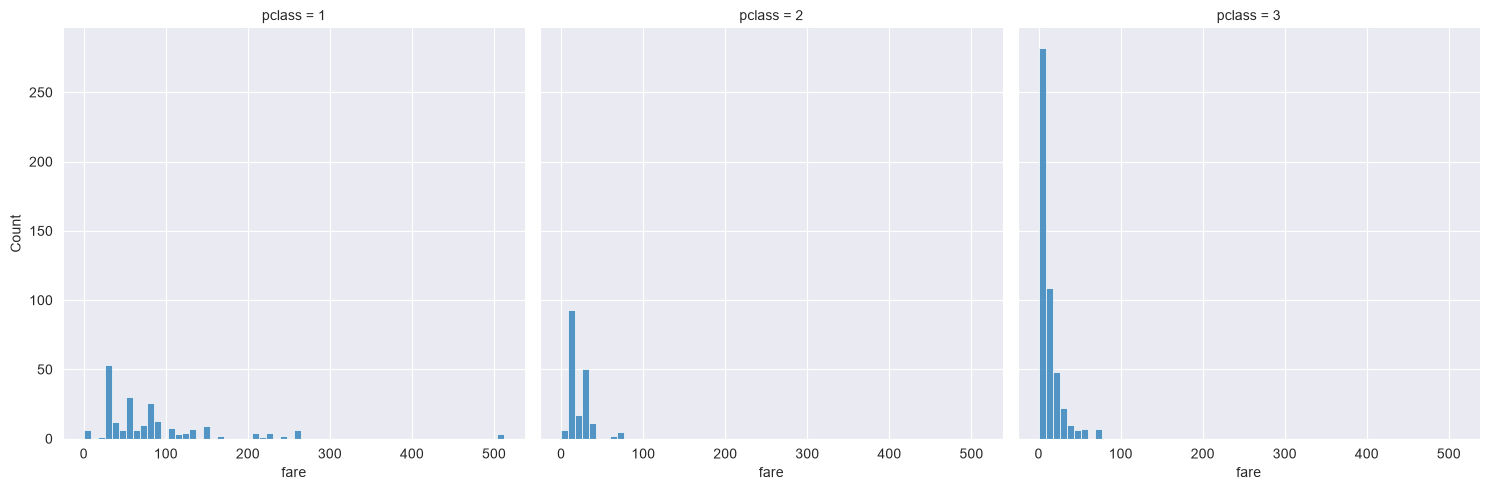

In [6]:
sns.displot(data=titanic, x="fare", col="pclass", kind="hist")
plt.show()

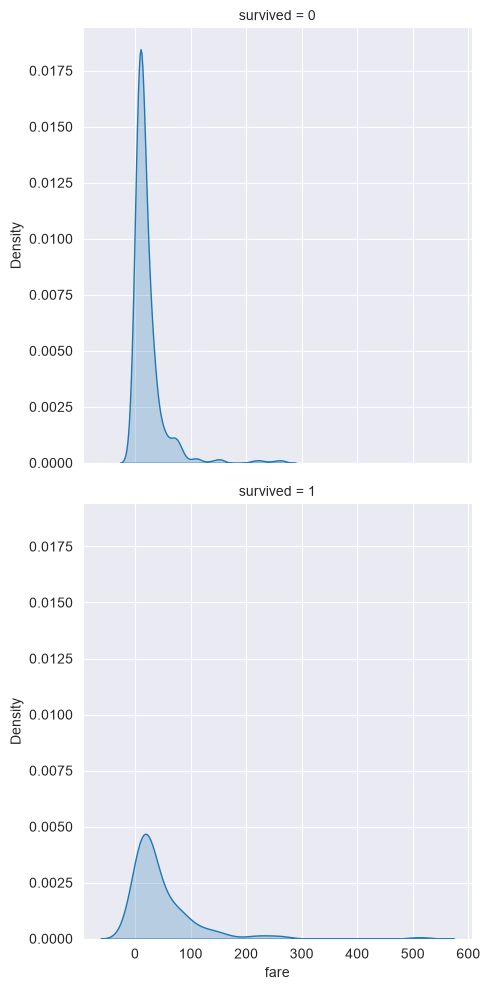

In [7]:
sns.displot(data=titanic, x="fare", row="survived", kind="kde", fill=True)
plt.show()

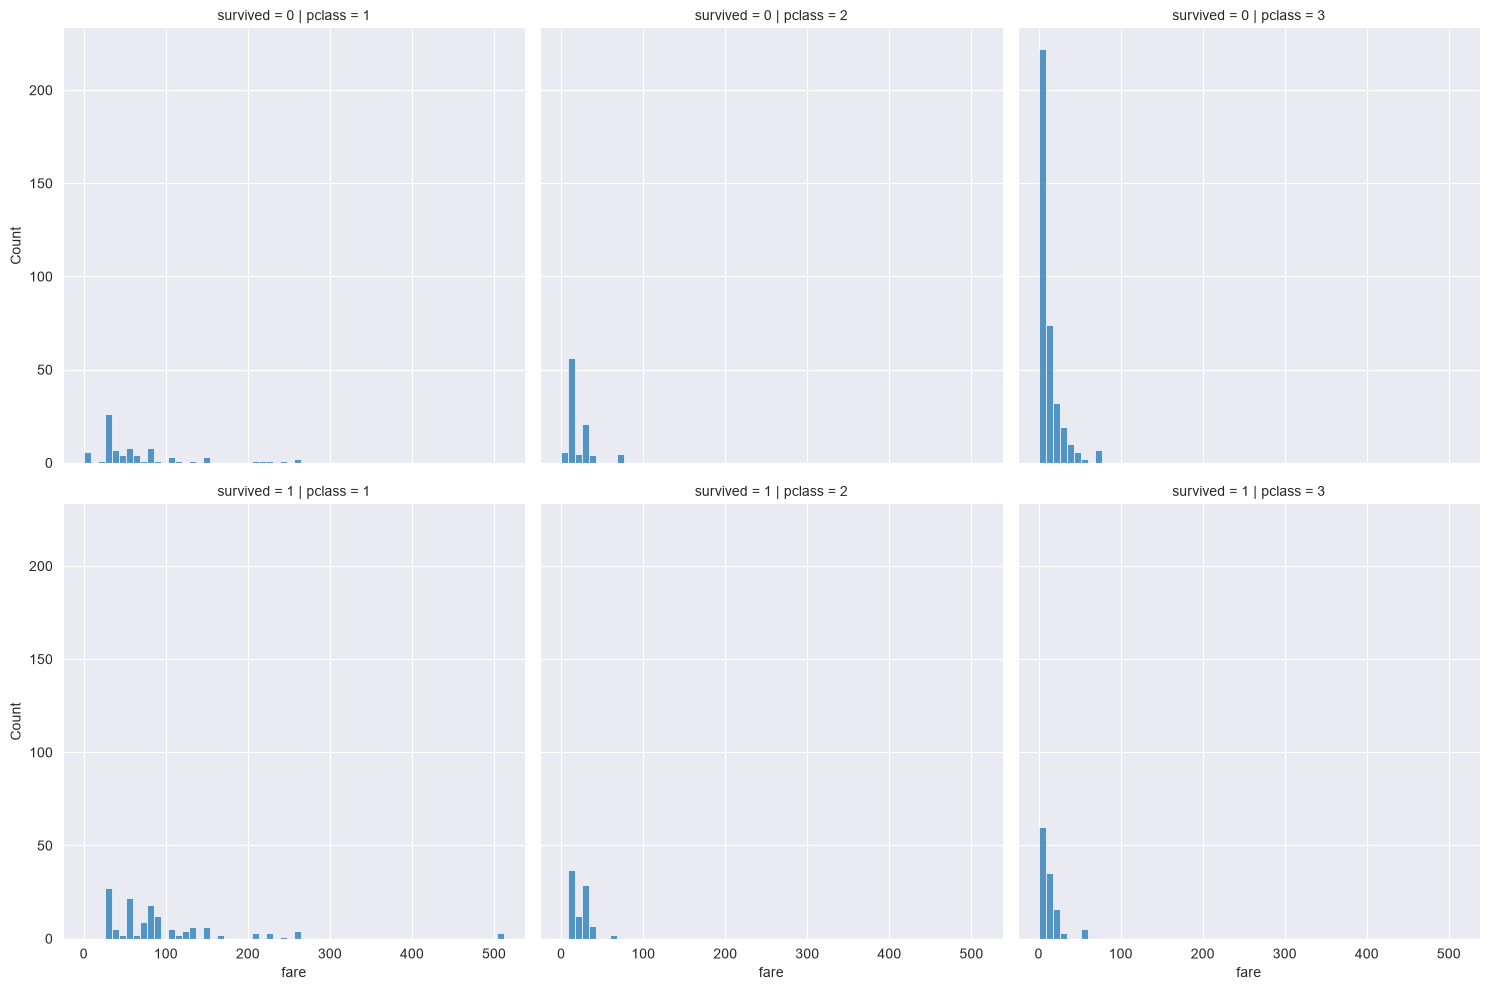

In [8]:
sns.displot(data=titanic, x="fare", col="pclass", row="survived")
plt.show()

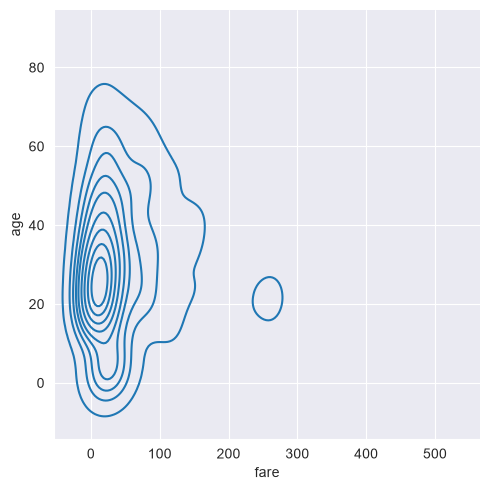

In [11]:
sns.displot(x="fare", y="age", data=titanic, kind="kde")
plt.show()

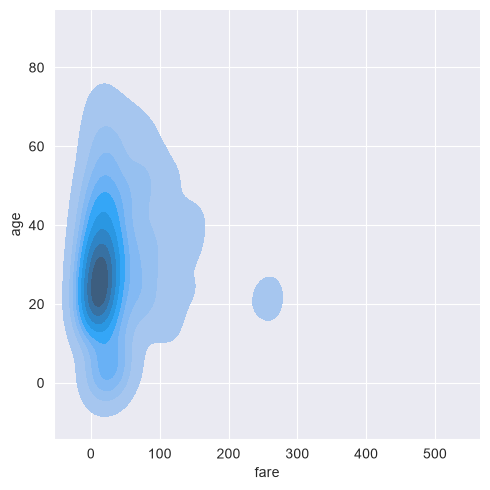

In [10]:
sns.displot(x="fare", y="age", data=titanic, kind="kde", fill=True)
plt.show()

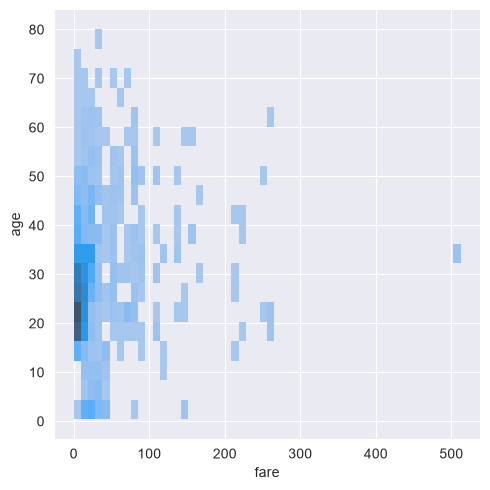

In [14]:
sns.displot(x="fare", y="age", data=titanic, kind="hist")
plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

tatinic = sns.load_dataset("titanic")
sns.set_style("darkgrid")

table = titanic.pivot_table(
    index=["sex"],
    columns=["class"],
    aggfunc="size",
    observed=False
)
print(table)
type(table)

class   First  Second  Third
sex                         
female     94      76    144
male      122     108    347


pandas.DataFrame

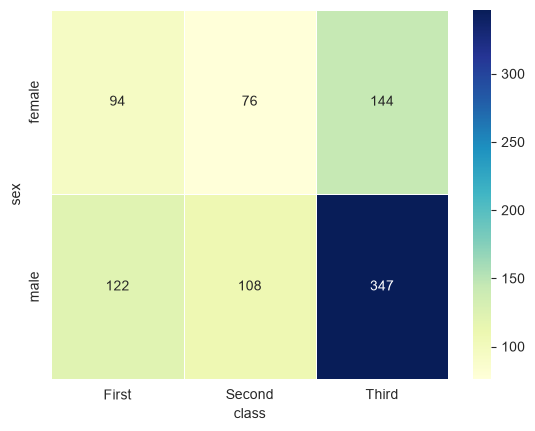

In [23]:
sns.heatmap(
    table,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=.5,
    cbar=True
)

plt.show()

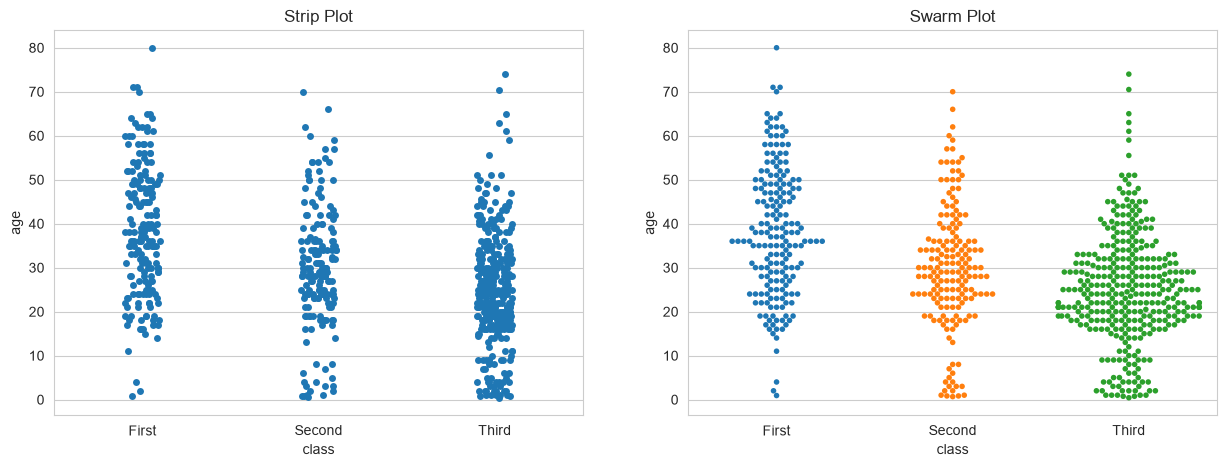

In [25]:
# 범주형 데이터의 산점도
sns.set_style("whitegrid")

fig, axes = plt.subplots(
    1, 2, figsize=(15, 5)
)

sns.stripplot(x="class",
              y="age",
              data=titanic,
              ax=axes[0])

sns.swarmplot(x="class",
              y="age",
              data=titanic,
              ax=axes[1],
              hue="class",
              size=4)

axes[0].set_title("Strip Plot")
axes[1].set_title("Swarm Plot")

plt.show()

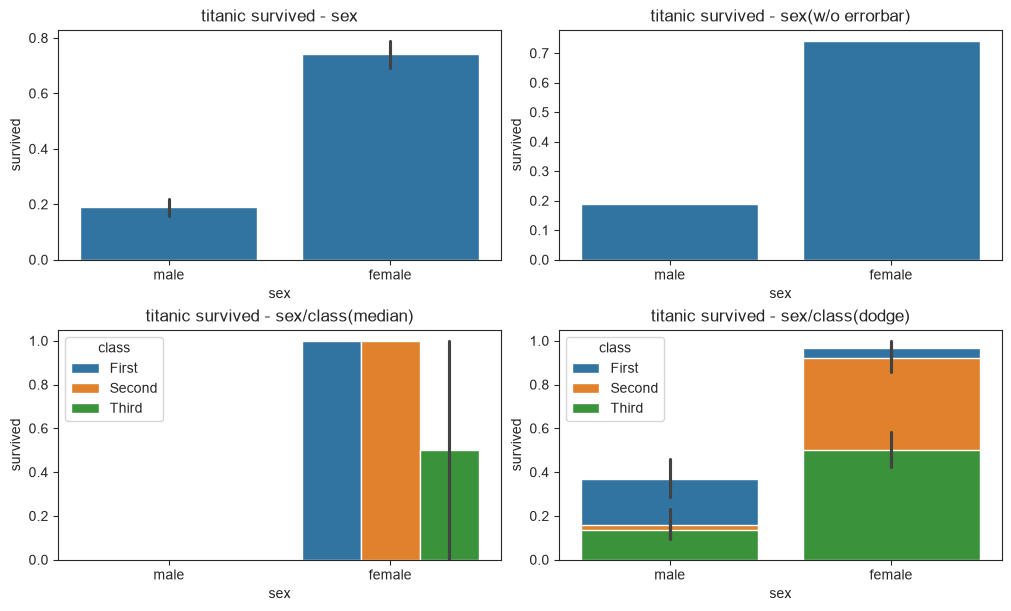

In [26]:
# 막대 그래프
sns.set_style('ticks')

fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)

sns.barplot(x='sex', y='survived', data=titanic, ax=axes[0,0]) 
sns.barplot(x='sex', y='survived', data=titanic, errorbar=None, ax=axes[0,1]) 
sns.barplot(x='sex', y='survived', hue='class', data=titanic, ax=axes[1,0], errorbar=('ci', 95), estimator='median') 
sns.barplot(x='sex', y='survived', hue='class', dodge=False, data=titanic, ax=axes[1,1])       

axes[0,0].set_title('titanic survived - sex')
axes[0,1].set_title('titanic survived - sex(w/o errorbar)')
axes[1,0].set_title('titanic survived - sex/class(median)')
axes[1,1].set_title('titanic survived - sex/class(dodge)')

plt.show()

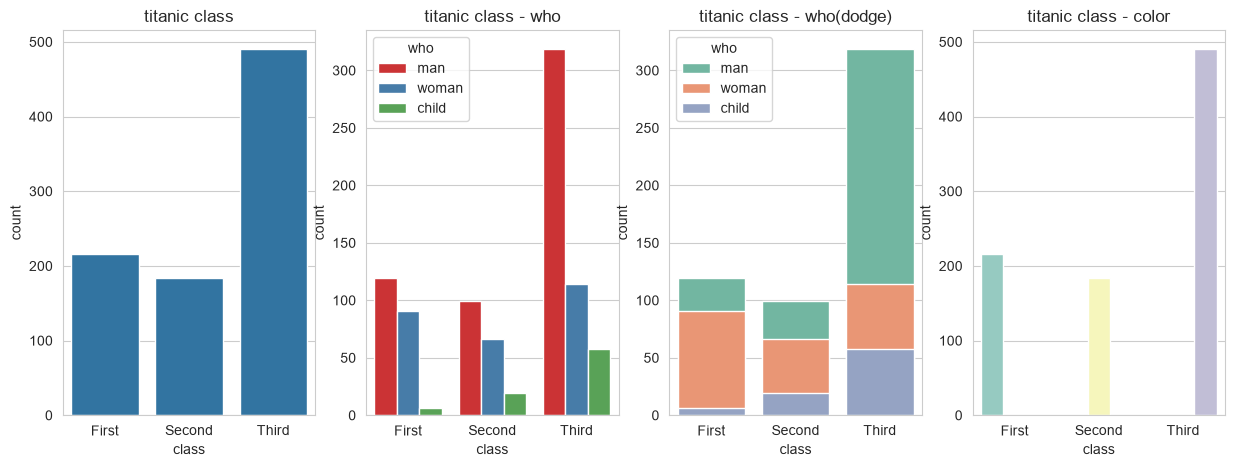

In [28]:
# 빈도 그래프
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

sns.countplot(x='class', data=titanic, ax=axes[0]) 
sns.countplot(x='class', hue='who', palette='Set1', dodge=True, data=titanic, ax=axes[1]) 
sns.countplot(x='class', hue='who', palette='Set2', dodge=False, data=titanic, ax=axes[2])  
sns.countplot(x='class', hue='class', palette='Set3', data=titanic, ax=axes[3]) 

axes[0].set_title('titanic class')
axes[1].set_title('titanic class - who')
axes[2].set_title('titanic class - who(dodge)')
axes[3].set_title('titanic class - color')

plt.show()

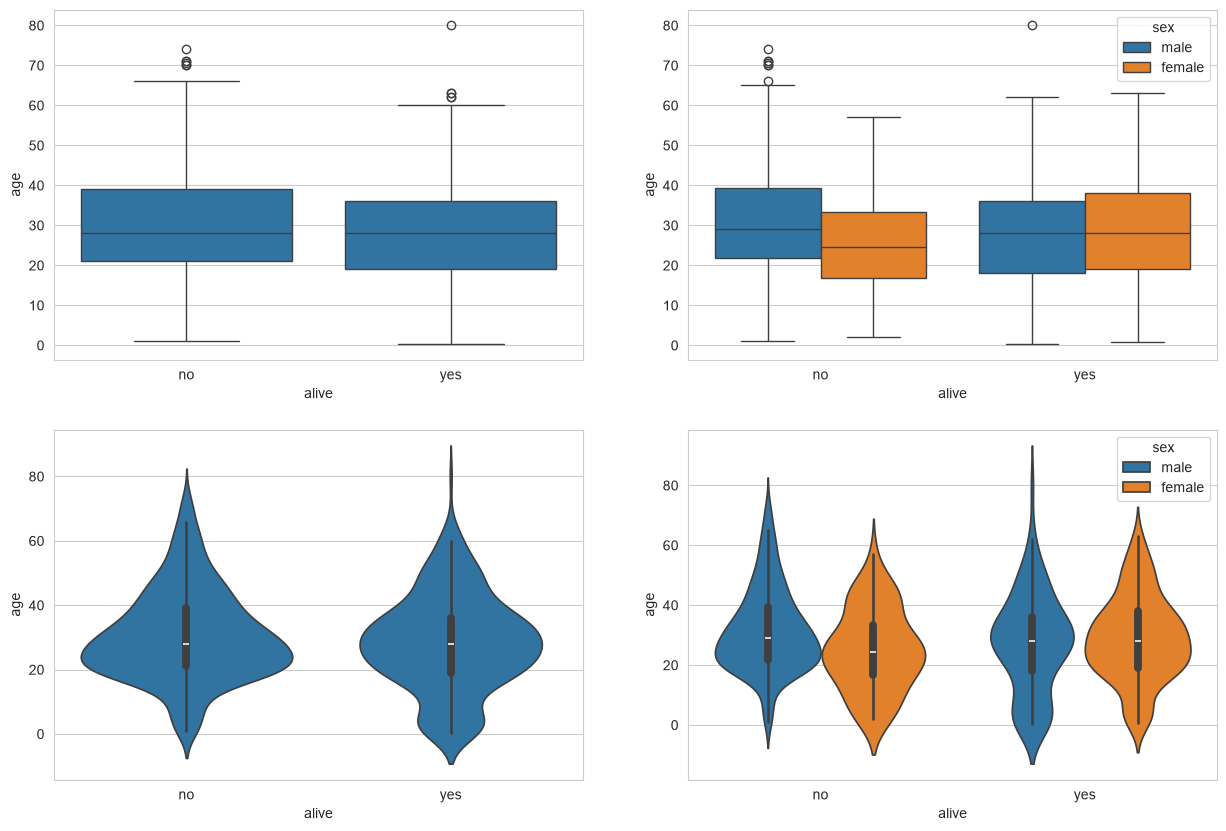

In [32]:
# 박스플롯

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x="alive",
            y="age",
            data=titanic,
            ax=axes[0, 0])

sns.boxplot(x="alive",
            y="age",
            hue="sex",
            data=titanic,
            ax=axes[0, 1])

sns.violinplot(x="alive",
            y="age",
            data=titanic,
            ax=axes[1, 0])

sns.violinplot(x="alive",
            y="age",
            hue="sex",
            data=titanic,
            ax=axes[1, 1])

plt.show()

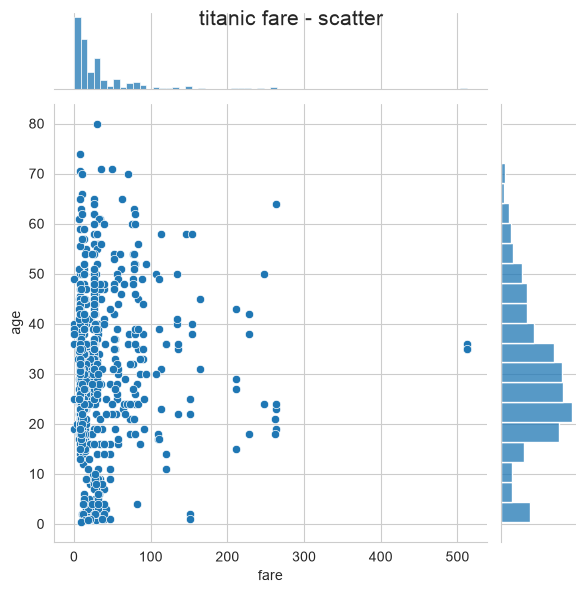

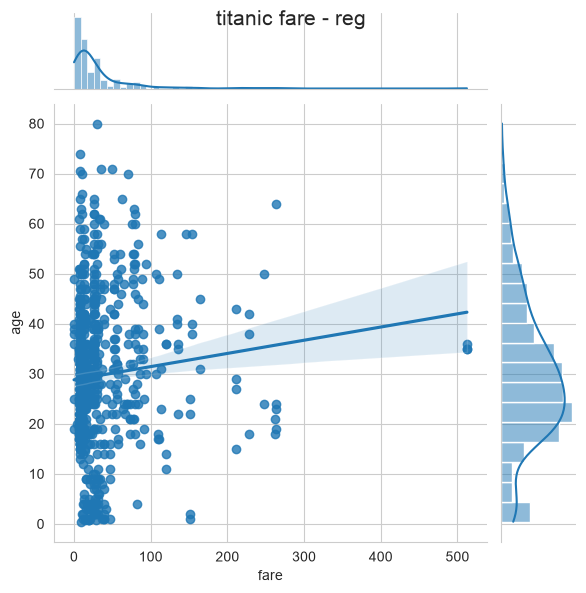

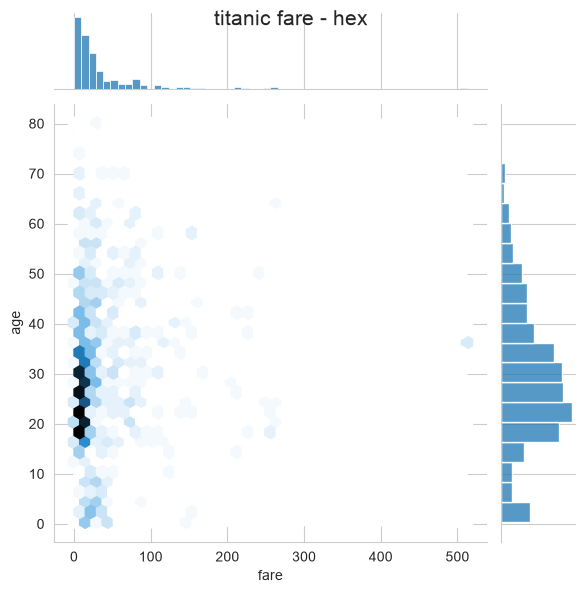

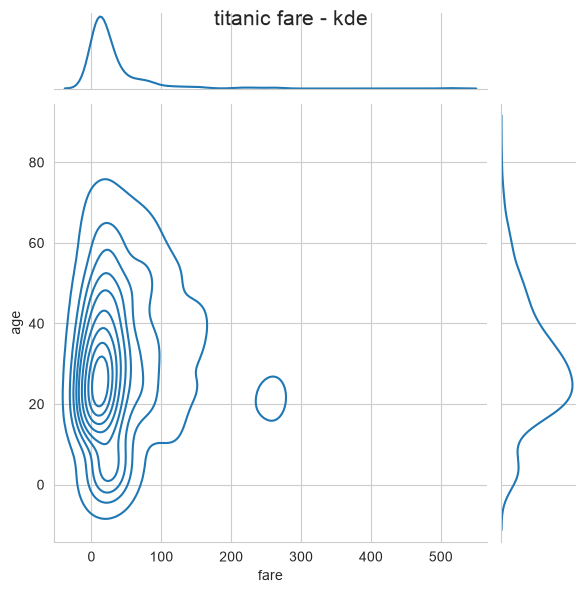

In [33]:
j1 = sns.jointplot(x='fare', y='age', data=titanic) 
j2 = sns.jointplot(x='fare', y='age', kind='reg', data=titanic)
j3 = sns.jointplot(x='fare', y='age', kind='hex', data=titanic)
j4 = sns.jointplot(x='fare', y='age', kind='kde', data=titanic) 

j1.fig.suptitle('titanic fare - scatter', size=15)
j2.fig.suptitle('titanic fare - reg', size=15)
j3.fig.suptitle('titanic fare - hex', size=15)
j4.fig.suptitle('titanic fare - kde', size=15)

plt.show()